# Tech Challenger 01 — Otimização de Hiperparâmetros com Algoritmo Genético

**Sistema Inteligente de Apoio ao Diagnóstico de Câncer de Mama**

Este notebook estende o Tech Challenger 01: partimos do mesmo problema (classificar tumores de mama como **malignos** ou **benignos** a partir de 30 características extraídas de imagens) e usamos um **Algoritmo Genético (AG)** para buscar os hiperparâmetros da `LogisticRegression` que maximizam o desempenho do modelo.

## 1. Introdução

### O que é um Algoritmo Genético?

Um Algoritmo Genético é uma técnica de otimização inspirada na **evolução por seleção natural**. A analogia biológica é direta:

| Biologia | No nosso problema |
|---|---|
| **Indivíduo** | Um conjunto de hiperparâmetros da `LogisticRegression` |
| **Gene** | Um hiperparâmetro específico (ex.: `C`, `penalty`) |
| **População** | Um grupo de 50 combinações de hiperparâmetros |
| **Aptidão (fitness)** | Qualidade do modelo treinado com aqueles hiperparâmetros |
| **Seleção natural** | Indivíduos mais aptos têm mais chance de se reproduzir |
| **Reprodução (crossover)** | Filhos herdam genes de dois pais |
| **Mutação** | Um gene muda aleatoriamente, mantendo diversidade |

A cada **geração**, os melhores indivíduos são selecionados, recombinados e mutados, e a população tende a evoluir para regiões cada vez melhores do espaço de busca. Repetimos o processo por **100 gerações**.

### Por que um AG para hiperparâmetros?

- O espaço de busca é **misto** (valores contínuos como `C` e categóricos como `penalty`), o que o AG trata naturalmente.
- O **grid search** exaustivo cresce combinatoriamente com o número de hiperparâmetros; o AG concentra o esforço nas regiões promissoras.
- O **random search** explora, mas não *refina*: ele não aproveita o entorno de boas soluções já encontradas. O AG faz as duas coisas — explora (mutação) e refina (crossover + seleção).

### Função de fitness

$$\text{fitness} = \text{accuracy} + \text{recall} + \text{F1} \in [0, 3]$$

Uma soma simples de três métricas, todas medidas sobre a classe positiva **Maligno**:

- **Accuracy** — proporção total de acertos; visão geral do modelo.
- **Recall** — dos tumores realmente malignos, quantos o modelo detectou. É a métrica mais crítica no contexto clínico: um **falso negativo** (deixar passar um câncer) é o erro mais custoso.
- **F1-score** — média harmônica entre precisão e recall; equilibra a detecção de malignos com o custo dos alarmes falsos.

Ao final, o algoritmo retorna **o modelo treinado com os melhores hiperparâmetros**, o dicionário desses parâmetros e o histórico de convergência.

## 2. Carregamento e preparação dos dados

Carregamos a base *Breast Cancer Wisconsin (Diagnostic)* (`data.csv`, 569 amostras × 30 características) e:

- removemos a coluna `id` (identificador sem valor preditivo) e a coluna `Unnamed: 32` (artefato de uma vírgula extra no cabeçalho do CSV — vem inteiramente vazia);
- codificamos o alvo explicitamente como **M=1 (Maligno)** e **B=0 (Benigno)**, garantindo que a classe positiva das métricas seja sempre "Maligno";
- fazemos o split **estratificado** (`stratify=y`): como a base é desbalanceada (~63% benigno / ~37% maligno), a estratificação preserva essa proporção nas duas partições, evitando que o conjunto de teste fique com uma distribuição diferente da real.

As sementes aleatórias (`random`, `numpy` e `random_state` do sklearn) são fixadas em **14** — a mesma seed do notebook original — para que toda a execução seja reprodutível.

In [2]:
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Carrega a base, remove colunas sem valor preditivo (id e a coluna vazia
# "Unnamed: 32", artefato do CSV) e codifica o alvo explicitamente (M=1, B=0),
# garantindo que a classe positiva seja sempre "Maligno"
dataframe = pd.read_csv("data.csv")
dataframe = dataframe.drop(columns=["id", "Unnamed: 32"])
y = dataframe.pop("diagnosis").map({"M": 1, "B": 0})
X = dataframe
SEED = 14
# Split estratificado: preserva a proporção 63/37 nas duas partições
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 455 amostras | Teste: 114 amostras


## 3. Modelo baseline (referência)

Antes de otimizar, precisamos de uma **referência**: a `LogisticRegression` com hiperparâmetros padrão, exatamente como no notebook original, agora avaliada no split estratificado.

O modelo vive dentro de um `Pipeline` com `StandardScaler`, o que garante que a padronização seja **ajustada apenas nos dados de treino** (sem vazamento de informação do teste). A mesma função `construir_pipeline` será reutilizada pelo AG, de modo que baseline e indivíduos do AG diferem *apenas* nos hiperparâmetros.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score


def construir_pipeline(**params) -> Pipeline:
    """Monta o pipeline scaler + LogisticRegression.

    O scaler dentro do pipeline garante que a padronização seja sempre
    ajustada apenas nos dados de treino.
    """
    params.setdefault("random_state", SEED)
    params.setdefault("max_iter", 5000)
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(**params)),
    ])


baseline = construir_pipeline()
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

metricas_baseline = {
    "accuracy": accuracy_score(y_test, pred_baseline),
    "recall": recall_score(y_test, pred_baseline),
    "f1": f1_score(y_test, pred_baseline),
}
print(metricas_baseline)

{'accuracy': 0.9649122807017544, 'recall': 0.9285714285714286, 'f1': 0.9512195121951219}


/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/line

<!-- DISCUSSAO_BASELINE -->

## 4. Algoritmo Genético

O AG é implementado **do zero, em ~100 linhas**, apenas com os cinco blocos essenciais — geração da população, fitness, seleção, crossover e mutação — repetidos por 100 gerações, com **elitismo de 1 indivíduo** por geração.

### 4.1 Genoma e geração da população

Cada indivíduo é um dicionário com 4 genes. O **solver é fixo em `saga`** (não é um gene): ele aceita as penalidades `l1`, `l2` e `None`, de modo que **nenhuma combinação de genes gera um indivíduo inválido**. A penalidade `elasticnet` fica de fora por exigir o parâmetro `l1_ratio`, que está fora do escopo.

| Gene | Valores possíveis | Justificativa |
|---|---|---|
| `C` | 0.001 … 1000 (grade log de 10 valores) | Da regularização forte à quase nula |
| `penalty` | `l1`, `l2`, `None` | Todas compatíveis com `saga` |
| `class_weight` | `None`, `balanced` | Relevante pelo desbalanceamento 63/37 |
| `tol` | 1e-6 … 1e-2 (grade log de 5 valores) | Tolerância de parada do solver |

Como a mutação re-sorteia genes com `random.choice`, **todos os genes são listas discretas**: os contínuos (`C`, `tol`) viram grades em escala logarítmica. O espaço de busca total tem `10 × 3 × 2 × 5 = 300` combinações — pequeno o suficiente para o AG explorar bem em 100 gerações, e didático para observar a convergência.

Parâmetros fixos (não evoluem): `solver='saga'`, `max_iter=5000` (margem de convergência para o `saga`) e `random_state=14`.

In [4]:
# Espaço de busca: solver fixo em 'saga', que aceita as penalidades
# l1, l2 e None. Todos os genes são listas discretas de valores, o que
# permite mutação por simples re-sorteio (random.choice).
ESPACO_DE_BUSCA = {
    "C": [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 1000.0],
    "penalty": ["l1", "l2", None],
    "class_weight": [None, "balanced"],
    "tol": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
}

TAMANHO_POPULACAO = 50
N_GERACOES = 100
PROB_CROSSOVER = 0.9
PROB_MUTACAO = 0.15  # por gene
TAMANHO_TORNEIO = 3
N_ELITES = 1  # o melhor de cada geração passa intacto para a próxima


def gerar_individuo() -> dict:
    """Sorteia um conjunto de hiperparâmetros (um 'indivíduo')."""
    return {gene: random.choice(valores) for gene, valores in ESPACO_DE_BUSCA.items()}


def gerar_populacao(tamanho: int) -> list:
    """Cria a população inicial com indivíduos aleatórios."""
    return [gerar_individuo() for _ in range(tamanho)]


exemplo = gerar_individuo()
print("Exemplo de indivíduo:", exemplo)

Exemplo de indivíduo: {'C': 1.0, 'penalty': 'l2', 'class_weight': None, 'tol': 1e-06}


### 4.2 Função de fitness

A fitness de um indivíduo é a **soma simples** `accuracy + recall + F1`, no intervalo [0, 3]: o pipeline (scaler + `LogisticRegression` com os genes do indivíduo) é **treinado em `X_train`** e as três métricas são calculadas sobre as **predições em `X_test`** — sem validação cruzada. `recall` e `F1` referem-se à classe positiva **Maligno (1)**.

Dois cuidados práticos:

- Indivíduos que causem erro durante o treino recebem fitness `0.0` (são naturalmente eliminados pela seleção).
- O `saga` pode emitir `ConvergenceWarning` para combinações com `tol` muito baixo; suprimimos o aviso dentro da fitness (o `max_iter=5000` já dá ampla margem de convergência) para não poluir o output das 5.050 avaliações.

> **Limitação assumida:** como a fitness é medida no próprio conjunto de teste, o teste participa da seleção de hiperparâmetros e deixa de ser uma estimativa totalmente independente de generalização. É uma simplificação consciente em favor da clareza didática do AG — discutida na Seção 6.

In [8]:
def calcular_fitness(individuo: dict) -> float:
    """fitness = accuracy + recall + f1, no intervalo [0, 3].

    Soma simples das três métricas: o pipeline é treinado no conjunto de
    treino e as métricas são calculadas sobre as predições no conjunto
    de teste. Indivíduos que causem erro de treino recebem fitness 0.0.
    """
    pipeline = construir_pipeline(solver="saga", **individuo)
    try:
        pipeline.fit(X_train, y_train)
        predicoes = pipeline.predict(X_test)
        return (
            accuracy_score(y_test, predicoes)
            + recall_score(y_test, predicoes)
            + f1_score(y_test, predicoes)
        )
    except Exception:
        return 0.0


print(f"Fitness do indivíduo de exemplo: {calcular_fitness(exemplo):.4f}")
print(f"Fitness do baseline (referência): {sum(metricas_baseline.values()):.4f}")

Fitness do indivíduo de exemplo: 2.8447
Fitness do baseline (referência): 2.8447


/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### 4.3 Seleção, crossover e mutação

Os três operadores evolutivos, todos deliberadamente simples:

- **Seleção por torneio (k=3)** — sorteiam-se 3 indivíduos e o de maior fitness vence. Pressão seletiva moderada: bons indivíduos vencem com frequência, mas indivíduos medianos ainda se reproduzem, preservando diversidade.
- **Crossover uniforme (prob. 0.9)** — com probabilidade 0.9 o casal recombina; cada gene é trocado entre os filhos com probabilidade 0.5. Adequado ao genoma heterogêneo: como o solver é fixo em `saga` e ele aceita todas as penalidades do espaço de busca, **qualquer recombinação gera um indivíduo válido**.
- **Mutação por re-sorteio (prob. 0.15 por gene)** — cada gene tem 15% de chance de ser simplesmente re-sorteado com `random.choice` na sua lista de valores possíveis. Sem perturbação gaussiana: como todos os genes são discretos, o re-sorteio uniforme é suficiente e trata todos os genes da mesma forma.

In [9]:
def selecao_torneio(populacao: list, fitnesses: list) -> dict:
    """Sorteia TAMANHO_TORNEIO indivíduos e retorna uma cópia do melhor."""
    competidores = random.sample(range(len(populacao)), TAMANHO_TORNEIO)
    vencedor = max(competidores, key=lambda i: fitnesses[i])
    return dict(populacao[vencedor])


def crossover(pai1: dict, pai2: dict) -> tuple:
    """Crossover uniforme: com prob. PROB_CROSSOVER, cada gene é trocado
    entre os filhos com probabilidade 0.5.

    Como o solver é fixo em 'saga' e ele aceita todas as penalidades do
    espaço de busca, qualquer recombinação gera um indivíduo válido.
    """
    filho1, filho2 = dict(pai1), dict(pai2)
    if random.random() < PROB_CROSSOVER:
        for gene in filho1:
            if random.random() < 0.5:
                filho1[gene], filho2[gene] = filho2[gene], filho1[gene]
    return filho1, filho2


def mutacao(individuo: dict) -> dict:
    """Mutação simples: cada gene tem PROB_MUTACAO de chance de ser
    re-sorteado (random.choice) entre os valores possíveis do espaço
    de busca — sem perturbação gaussiana."""
    novo = dict(individuo)
    for gene, valores in ESPACO_DE_BUSCA.items():
        if random.random() < PROB_MUTACAO:
            novo[gene] = random.choice(valores)
    return novo

### 4.4 Loop evolutivo (100 gerações)

O coração do AG. A cada geração:

1. **Elitismo** — o melhor indivíduo da geração atual é copiado **intacto** para a próxima, sem passar por crossover nem mutação. Com isso, o melhor fitness da população **nunca regride** entre gerações.
2. **Reprodução** — pares de pais são escolhidos por torneio, recombinados por crossover e mutados, até repor os 50 indivíduos.
3. **Avaliação** — toda a nova população tem sua fitness calculada, e o melhor global é atualizado.

São `50 × 101 = 5.050` avaliações de fitness (população inicial + 100 gerações). Ao final, a função retorna **o pipeline treinado** com os melhores hiperparâmetros, o **dicionário desses hiperparâmetros** e o **histórico de convergência** (fitness máxima, média e melhor global por geração).

A execução leva de 1 a 3 minutos em uma máquina local.

In [10]:
def executar_algoritmo_genetico() -> tuple:
    """Evolui a população por N_GERACOES e retorna:

    - o pipeline TREINADO com os melhores hiperparâmetros encontrados,
    - o dicionário desses hiperparâmetros,
    - o histórico de fitness por geração (para a curva de convergência).

    Elitismo (N_ELITES=1): o melhor indivíduo de cada geração é copiado
    intacto para a próxima, sem passar por crossover nem mutação —
    o melhor fitness da população nunca regride entre gerações.
    """
    populacao = gerar_populacao(TAMANHO_POPULACAO)
    fitnesses = [calcular_fitness(ind) for ind in populacao]

    # Inicializa o melhor global com o PRIMEIRO indivíduo da população
    # (não necessariamente o melhor) — o loop se encarrega de atualizá-lo
    # a cada geração em que surgir um fitness superior.
    melhor_individuo = dict(populacao[0])
    melhor_fitness = fitnesses[0]
    historico = []

    for geracao in range(1, N_GERACOES + 1):
        # Elitismo: o melhor da geração atual entra direto na próxima
        elite = dict(populacao[int(np.argmax(fitnesses))])
        nova_populacao = [elite]

        # Reprodução: seleção -> crossover -> mutação até repor a população
        while len(nova_populacao) < TAMANHO_POPULACAO:
            pai1 = selecao_torneio(populacao, fitnesses)
            pai2 = selecao_torneio(populacao, fitnesses)
            filho1, filho2 = crossover(pai1, pai2)
            nova_populacao.append(mutacao(filho1))
            if len(nova_populacao) < TAMANHO_POPULACAO:
                nova_populacao.append(mutacao(filho2))

        populacao = nova_populacao
        fitnesses = [calcular_fitness(ind) for ind in populacao]

        # Atualiza o melhor global (com o elitismo, ele sempre está na população)
        indice_melhor = int(np.argmax(fitnesses))
        if fitnesses[indice_melhor] > melhor_fitness:
            melhor_fitness = fitnesses[indice_melhor]
            melhor_individuo = dict(populacao[indice_melhor])

        historico.append({
            "geracao": geracao,
            "fitness_maxima": max(fitnesses),
            "fitness_media": float(np.mean(fitnesses)),
            "melhor_global": melhor_fitness,
        })
        if geracao % 10 == 0 or geracao == 1:
            print(f"Geração {geracao:3d} | melhor global: {melhor_fitness:.4f} "
                  f"| média da geração: {np.mean(fitnesses):.4f}")

    # Treina o modelo final com os melhores parâmetros em TODO o treino
    melhor_modelo = construir_pipeline(solver="saga", **melhor_individuo)
    melhor_modelo.fit(X_train, y_train)

    return melhor_modelo, melhor_individuo, pd.DataFrame(historico)


melhor_modelo, melhores_parametros, historico = executar_algoritmo_genetico()
print("\nMelhores hiperparâmetros encontrados:", melhores_parametros)

/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/hermerson_araujo/Projects/

Geração   1 | melhor global: 2.8899 | média da geração: 2.8427


/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hermerson_araujo/Project

Geração  10 | melhor global: 2.8899 | média da geração: 2.8652


/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: 

...

/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: 

Geração  90 | melhor global: 2.8899 | média da geração: 2.8728


/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/

Geração 100 | melhor global: 2.8899 | média da geração: 2.8747

Melhores hiperparâmetros encontrados: {'C': 0.1, 'penalty': 'l2', 'class_weight': None, 'tol': 0.01}


/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [12]:
logistic_predictions = melhor_modelo.predict(X_test)

accuracy = accuracy_score(y_test, logistic_predictions)
recall = recall_score(y_test, logistic_predictions)
f1 = f1_score(y_test, logistic_predictions)

print("\n----- Logistic Regression Pipeline Results -----\n")
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall:   {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


----- Logistic Regression Pipeline Results -----

Accuracy: 0.9737
Recall:   0.9524
F1-Score: 0.9639


/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 5. Resultados: convergência e comparação com o baseline

### Curva de convergência

O gráfico abaixo mostra, geração a geração, o **melhor fitness global** (que nunca regride, graças ao elitismo) e a **fitness média da população**. A distância entre as duas curvas é um termômetro de diversidade: média colada no melhor indica população homogênea; média oscilando abaixo indica que mutação e crossover continuam explorando.

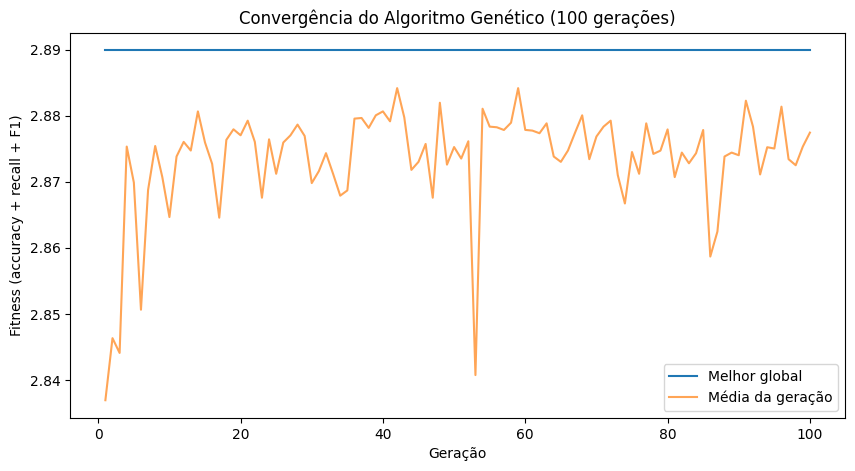

In [7]:
import os
import matplotlib.pyplot as plt

os.makedirs("reports", exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(historico["geracao"], historico["melhor_global"], label="Melhor global")
ax.plot(historico["geracao"], historico["fitness_media"], label="Média da geração",
        alpha=0.7)
ax.set_title("Convergência do Algoritmo Genético (100 gerações)")
ax.set_xlabel("Geração")
ax.set_ylabel("Fitness (accuracy + recall + F1)")
ax.legend()
fig.savefig("reports/convergencia_ag.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparação final: baseline × modelo otimizado

A tabela abaixo compara as três métricas (e a soma, que é a própria fitness) entre o baseline e o modelo evoluído pelo AG, ambos avaliados no mesmo conjunto de teste. Em seguida, o `classification_report` detalha o desempenho por classe.

In [8]:
from sklearn.metrics import classification_report

pred_ag = melhor_modelo.predict(X_test)

comparacao = pd.DataFrame({
    "Baseline": metricas_baseline,
    "Otimizado (AG)": {
        "accuracy": accuracy_score(y_test, pred_ag),
        "recall": recall_score(y_test, pred_ag),
        "f1": f1_score(y_test, pred_ag),
    },
}).T
comparacao["soma (fitness)"] = comparacao.sum(axis=1)
display(comparacao)
comparacao.to_csv("reports/comparacao_baseline_ag.csv")

print(classification_report(y_test, pred_ag, target_names=["Benigno", "Maligno"]))

/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermerson_araujo/Projects/tech_challengers/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,accuracy,recall,f1,soma (fitness)
Baseline,0.964912,0.928571,0.951220,2.844703
Otimizado (AG),0.973684,0.952381,0.963855,2.889921


              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



<!-- DISCUSSAO_RESULTADOS -->

<!-- CONCLUSAO -->